# Predoc Data Task Practice #1
#### Gavin Qu, 02-24-2026



This sample data task will use resource-level scheduled output data from the Electricity Reliability Council of Texas (ERCOT). For the first few questions, use the file `ercot_resource_output.csv`.

---

## Question 1

How many unique values does the variable `Resource Name` take in the data? The variable `QSE`? <br>
`Answer: There are 1121 unique values for Resource Name and 194 unique values for QSE.`

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("./data/ercot_resource_output.csv")
print(f"data types: {df.info()}")

unique_val_resource = df['resource_name'].nunique()
print(f"Unique value count of [resource_name]: {unique_val_resource}")
unique_val_qse = df['qse'].nunique()
print(f"Unique value count of [QSE]: {unique_val_qse}")

<class 'pandas.DataFrame'>
RangeIndex: 3008438 entries, 0 to 3008437
Data columns (total 5 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   sced_time_stamp         str    
 1   qse                     str    
 2   resource_name           str    
 3   telemetered_net_output  float64
 4   resource_status         str    
dtypes: float64(1), str(4)
memory usage: 114.8 MB
data types: None
Unique value count of [resource_name]: 1121
Unique value count of [QSE]: 194


## Question 2

What is a QSE? Do a quick online search for this ERCOT acronym. Provide a brief (1-3 sentences) definition for QSE as used in ERCOT's market for electricity. <br>
`Answer: Qualified Scheduling Entity (QSE) are responsible for submitting bids/offers on behalf of resource entities or load serving entities such as retail electric providers and physical power plants. Essentially, QSEs acts ast the middlemen to bid or sell energy in the day-ahead market and the real-time market, balancing the supply and demand in the energy market. They are also responsible for financially settling with ERCOT(Electric Reliability Council of Texas).`

## Question 3

Find the set of unique QSE/Resource Name pairs. Answer the following questions.

### 3(a)

Is it ever the case that a single QSE is paired to multiple resource names? What might this indicate about the relationship between QSEs and Resource Names? What are the 10 largest QSEs in terms of the number of unique Resource Names they are paired to in the data?
<br>
`Answer: Yes, there are less unique QSEs comparing to resource names, this happens quite often by a quick visual of the dataset as well. It's indicative of a one to many relationship where QSEs manage multiple power plants.`

In [2]:
df_subset = df.loc[:, ['qse', 'resource_name']].drop_duplicates()
qse_counts = df_subset.value_counts(['qse'])
print(qse_counts.head(10))

qse   
QTENSK    173
QLUMN      75
QNRGTX     50
QCALP      44
QECNR      40
QAEN       34
QLCRA      32
QCPSE      25
QTEN23     24
QSHEL2     22
Name: count, dtype: int64


### 3(b)

Is it ever the case that a single Resource Name is paired to more than one QSE in the data? For how many Resource Names is this true for? Why might a single Resource Name pair with multiple QSEs in the data? **Hint:** Look at how pairs change over time. <br>
`Answer: Yes, there are 6 of those instances. This could happen because of buyer and seller are different for the same resources or ownership change of the power plants, or that qse contracts expired and new broker was found which could explain the same switching date for the same QSEs.`

In [3]:
resource_counts = df_subset.value_counts(['resource_name'])
multi_resource = resource_counts[resource_counts > 1]
multi_resource

resource_name  
MUSTNGCK_BES1      2
MUSTNGCK_SOLAR1    2
MUSTNGCK_SOLAR2    2
STAM_SLR_BESS1     2
STAM_SLR_SOLAR1    2
STAM_SLR_SOLAR2    2
Name: count, dtype: int64

In [4]:
# The pandas equivalent of R's: df %>% group_by() %>% filter() %>% arrange()
multi_qse_pairs = (
    df_subset.groupby('resource_name')
    .filter(lambda x: x['qse'].nunique() > 1)
    .sort_values('resource_name')
)

print(multi_qse_pairs)

            qse    resource_name
566      QENEL5    MUSTNGCK_BES1
279638   QENE10    MUSTNGCK_BES1
567      QENEL5  MUSTNGCK_SOLAR1
279639   QENE10  MUSTNGCK_SOLAR1
568      QENEL5  MUSTNGCK_SOLAR2
279640   QENE10  MUSTNGCK_SOLAR2
792      QENEL5   STAM_SLR_BESS1
2253533  QENE12   STAM_SLR_BESS1
793      QENEL5  STAM_SLR_SOLAR1
2253534  QENE12  STAM_SLR_SOLAR1
794      QENEL5  STAM_SLR_SOLAR2
2253535  QENE12  STAM_SLR_SOLAR2


## Question 4

Now turn to `resource_type.csv`.

### 4(a)

How many unique, non-missing values does `Resource Type` take? Can you find definitions for them? (No need to define all of them, just attempt a few.)
`Answer: There are 15 unique, non-missing values for resource type, wind, solar, hydroelectric, nuclear, just to name a few. `

In [5]:
df_type = pd.read_csv("./data/ercot_resource_types.csv")
print(f"{df_type.info()}\n")
print(f"unique count of resource type: {df_type['resource_type'].nunique()}\n")
print(f"sample of unique resource type: {df_type['resource_type'].drop_duplicates().head(15)}")

<class 'pandas.DataFrame'>
RangeIndex: 1121 entries, 0 to 1120
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   resource_name  1121 non-null   str  
 1   resource_type  1117 non-null   str  
dtypes: str(2)
memory usage: 17.6 KB
None

unique count of resource type: 15

sample of unique resource type: 0         DSL
3      SCGT90
6        WIND
11     PWRSTR
15      HYDRO
17     CCGT90
27       PVGR
47     SCLE90
111     GSREH
148    CCLE90
153     CLLIG
179     GSSUP
206       NUC
257    GSNONR
293     RENEW
Name: resource_type, dtype: str


### 4(b)

Are there any empty strings in the resource type column? Which resource names are missing their type? Can you guess what the missing values should be? Fill in the missing values with your guesses (you will carry your filled in guesses for the remainder of the data task).
`Answer: There are four resource names where resource type is missing, they are solar and wind companies.`

In [6]:
empty_mask = (df_type['resource_type'].isna()) | (df_type['resource_type'] == '')
print(df_type[empty_mask])

       resource_name resource_type
341  GALLOWAY_SOLAR1           NaN
711  ROSELAND_SOLAR3           NaN
791  SSPURTWO_WIND_1           NaN
814   SWEETWN2_WND24           NaN


In [7]:
# Impute missing string based on suffix in resource name
df_type.loc[df_type['resource_name'].str.contains('SOLAR', na=False), 'resource_type'] = 'PVGR'
df_type.loc[df_type['resource_name'].str.contains('WIND|WND', na=False), 'resource_type'] = 'WIND'

# Verify the nan are gone
print(df_type[df_type['resource_type'].isna()])

Empty DataFrame
Columns: [resource_name, resource_type]
Index: []


## Question 5

Based on the following definitions, use the resource type column to make a "Fuel Type" column. After doing so, merge Fuel Type and Resource Type onto `ercot_resource_output.csv` using Resource Name (you should end up with 6 unique values of Fuel Type).

- DSL - Other
- SCGT90 - Natural Gas
- WIND - Wind
- PWRSTR - Other
- HYDRO - Other
- CCGT90 - Natural Gas
- PVGR - Solar
- SCLE90 - Natural Gas
- GSREH - Natural Gas
- CCLE90 - Natural Gas
- CLLIG - Coal
- GSSUP - Natural Gas
- NUC - Nuclear
- GSNONR - Natural Gas
- RENEW - Other

In [8]:
fuel_mapping = {
    'DSL': 'Other',
    'SCGT90': 'Natural Gas',
    'WIND': 'Wind', 
    'PWRSTR': 'Other', 
    'HYDRO': 'Other',
    'CCGT90': 'Natural Gas',
    'PVGR': 'Solar',
    'SCLE90': 'Natural Gas',
    'GSREH': 'Natural Gas',
    'CCLE90': 'Natural Gas',
    'CLLIG': 'Coal',
    'GSSUP': 'Natural Gas',
    'NUC': 'Nuclear',
    'GSNONR': 'Natural Gas',
    'RENEW': 'Other'
}

df_type['fuel_type'] = df_type['resource_type'].map(fuel_mapping)
print(df_type.nunique())

resource_name    1121
resource_type      15
fuel_type           6
dtype: int64


In [9]:
# merge on resource name
merged_df = df.merge(df_type, left_on='resource_name', right_on='resource_name', how='left')
merged_df.to_csv("./data/merged.csv")
merged_df.head()

,sced_time_stamp,qse,resource_name,telemetered_net_output,resource_status,resource_type,fuel_type
0,01/22/2023 00:00,QGOLDN,AEEC_ANTLP_1,0.000,EMRSWGR,DSL,Other
1,01/22/2023 00:00,QGOLDN,AEEC_ANTLP_2,54.371,ON,DSL,Other
2,01/22/2023 00:00,QGOLDN,AEEC_ANTLP_3,45.387,ON,DSL,Other
3,01/22/2023 00:00,QGOLDN,AEEC_ELK_1,0.000,EMRSWGR,SCGT90,Natural Gas
4,01/22/2023 00:00,QGOLDN,AEEC_ELK_2,0.000,OFF,SCGT90,Natural Gas


## Question 6
Plot the following:
### 6(a)
Output summed by day.
`Answer: the pattern happened during the historic snow storm in Texas that left much of the state without power`

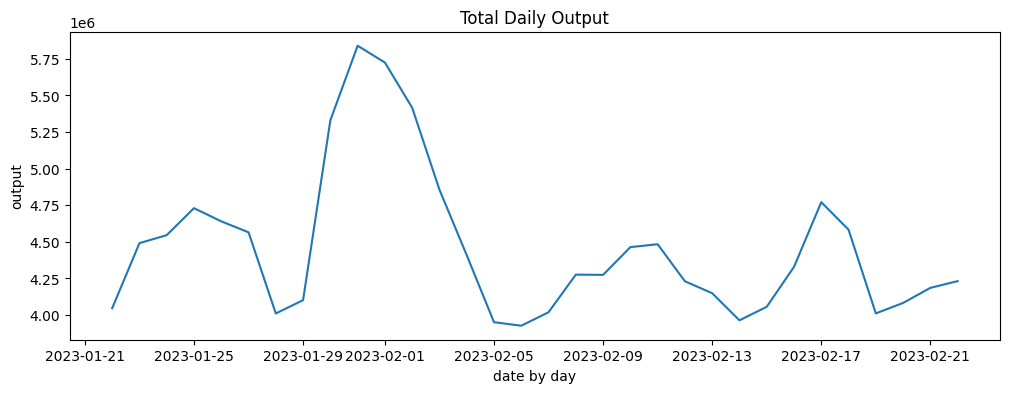

In [14]:
import matplotlib.pyplot as plt

# convert to time component first
merged_df['sced_time_stamp'] = pd.to_datetime(merged_df['sced_time_stamp'])
merged_df['date'] = merged_df['sced_time_stamp'].dt.date

daily_output = merged_df.groupby('date')['telemetered_net_output'].sum()
daily_output.plot(kind='line', title="Total Daily Output", figsize=(12,4))
plt.ylabel('output')
plt.xlabel('date by day')
plt.show()

### 6(b)

Output summed by hour-of-day (hours 0-23)
`Asnwer: I see the typical energy usage pattern which peaks early morning and another peak after work when AC usage is highest in Texas`

[]

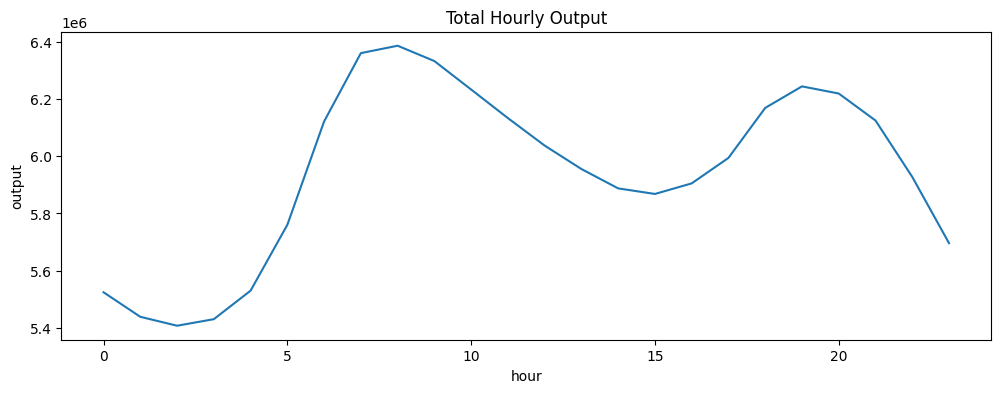

In [15]:
merged_df['hour'] = merged_df['sced_time_stamp'].dt.hour
hourly_output = merged_df.groupby('hour')['telemetered_net_output'].sum()
hourly_output.plot(kind='line', title="Total Hourly Output", figsize=(12,4))
plt.ylabel('output')
plt.plot()

### 6(c)
Output summed by hour-of-day and by Fuel Type (the variable you defined in 5.)

`Answer: solar drops off during non-sunlight hours whereas wind is the inverse of that, natural gas follows a on-demand pattern which correlates with peak usage hours.`

[]

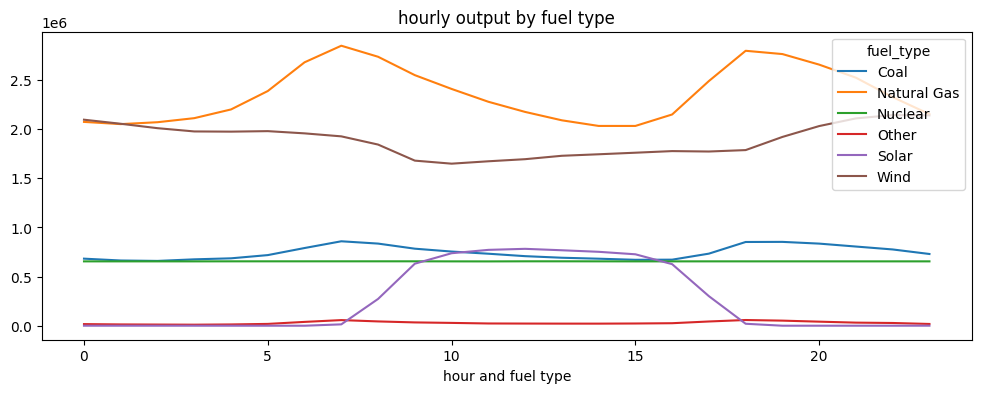

In [ ]:
hourly_fuel = merged_df.groupby(['hour','fuel_type'])['telemetered_net_output'].sum().unstack() # unstack into columns wide format
hourly_fuel.plot(kind='line', title='hourly output by fuel type', figsize=(12,4))
plt.xlabel("hour and fuel type")
plt.plot()

## Question 7

Looking at the plot from 6(a), does this data look stationary? Using the data summed at the daily level, test for a unit root and interpret the result. Now calculate its first difference and plot it. Does it look stationary?

`answer: looking at 6a, it does look stationary even with the initial shock. since p-value < 0.05 we can reject the null and confirm the earlier statement that data does not have unit root`

In [20]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(daily_output.dropna())

print(f"ADF statistic and p-value: {adf_result[:2]}")

ADF statistic and p-value: (np.float64(-3.5694139609588458), np.float64(0.006373421029541755))


If a series is non-stationary, standard regression models will give you spurious, garbage results. We fix this by "differencing" the data.The first difference is simply today's value minus yesterday's value ($\Delta Y_t = Y_t - Y_{t-1}$). This transforms the data from "absolute electricity output" to "the daily change in electricity output," which usually strips away the trend and leaves behind a stationary series.

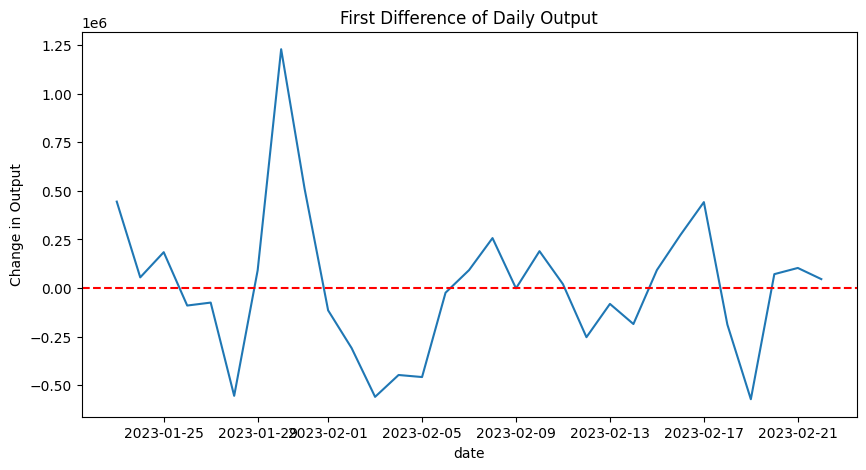

In [21]:
# Calculate the first difference and drop the first row (which becomes NaN)
daily_diff = daily_output.diff().dropna()

# Plot the differenced data
daily_diff.plot(kind='line', title='First Difference of Daily Output', figsize=(10, 5))
import matplotlib.pyplot as plt
plt.axhline(0, color='red', linestyle='--') # Adds a line at zero for reference
plt.ylabel('Change in Output')
plt.show()

## Question 8

Now sum output at the hourly level (day-hour, not hour-of-day). Fit an AR(3) model on electricity output. Do you believe an AR model is a good fit? Why or why not?
An AR(3) model (Autoregressive model of order 3) predicts the current value of a time series based strictly on its previous three values (lags).Mathematically, it looks like this:$Y_t = \beta_0 + \beta_1 Y_{t-1} + \beta_2 Y_{t-2} + \beta_3 Y_{t-3} + \epsilon_t$

`Answer: AR3 is missing the previous day's pattern completely and its prediction will pick up a lot of noise as the previous 3 hours are not relevant outside of peak and troughs. `

In [22]:
# Round timestamps down to the nearest hour to create a continuous 'day-hour' timeline
merged_df['day_hour'] = merged_df['sced_time_stamp'].dt.floor('h')

# Group by this new continuous hourly column and sum
continuous_hourly = merged_df.groupby('day_hour')['telemetered_net_output'].sum()

print(continuous_hourly.head())

day_hour
2023-01-22 00:00:00    158135.12221
2023-01-22 01:00:00    155767.47510
2023-01-22 02:00:00    155209.54402
2023-01-22 03:00:00    155748.62620
2023-01-22 04:00:00    157538.84676
Name: telemetered_net_output, dtype: float64


In [23]:
from statsmodels.tsa.ar_model import AutoReg

# drop any potential NaNs to ensure statsmodels doesn't throw an error
model_ar3 = AutoReg(continuous_hourly.dropna(), lags=3)
results_ar3 = model_ar3.fit()

print(results_ar3.summary())

                              AutoReg Model Results                               
Dep. Variable:     telemetered_net_output   No. Observations:                  768
Model:                         AutoReg(3)   Log Likelihood               -7091.309
Method:                   Conditional MLE   S.D. of innovations           2567.650
Date:                    Thu, 26 Feb 2026   AIC                          14192.618
Time:                            18:18:54   BIC                          14215.817
Sample:                        01-22-2023   HQIC                         14201.549
                             - 02-22-2023                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                      3643.8777    721.013      5.054      0.000    2230.718    5057.038
telemetered_net_output.L1     2.2162      0.031     71

/Users/gavinqu/dev/predoc/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


## Question 9
Run the following dummy variable regressions and interpret the coefficients:
### 9(a)
Output regressed on a set of indicator variables for each Fuel Type in the data.

In [24]:
import statsmodels.formula.api as smf

# Extract day of the week (e.g., 'Monday', 'Tuesday')
merged_df['day_of_week'] = merged_df['sced_time_stamp'].dt.day_name()

# Extract the week number (e.g., 1, 2, 3...)
merged_df['week'] = merged_df['sced_time_stamp'].dt.isocalendar().week

In [25]:
model_9a = smf.ols('telemetered_net_output ~ C(fuel_type)', data=merged_df).fit()
print(model_9a.summary())

                              OLS Regression Results                              
Dep. Variable:     telemetered_net_output   R-squared:                       0.264
Model:                                OLS   Adj. R-squared:                  0.264
Method:                     Least Squares   F-statistic:                 2.157e+05
Date:                    Thu, 26 Feb 2026   Prob (F-statistic):               0.00
Time:                            18:23:08   Log-Likelihood:            -1.8371e+07
No. Observations:                 3008438   AIC:                         3.674e+07
Df Residuals:                     3008432   BIC:                         3.674e+07
Df Model:                               5                                         
Covariance Type:                nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

### 9(b)
Output regressed on a set of indicator variables for each day of the week (Sun, Mon, Tues, etc.)

In [26]:
model_9b = smf.ols('telemetered_net_output ~ C(day_of_week)', data=merged_df).fit()
print(model_9b.summary())

                              OLS Regression Results                              
Dep. Variable:     telemetered_net_output   R-squared:                       0.000
Model:                                OLS   Adj. R-squared:                  0.000
Method:                     Least Squares   F-statistic:                     135.5
Date:                    Thu, 26 Feb 2026   Prob (F-statistic):          2.18e-172
Time:                            18:24:00   Log-Likelihood:            -1.8832e+07
No. Observations:                 3008438   AIC:                         3.766e+07
Df Residuals:                     3008431   BIC:                         3.766e+07
Df Model:                               6                                         
Covariance Type:                nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

### 9(c)
Output regressed on a set of indicator variables for each week in the data.

What factors might explain the values of the coefficients you found?

`answer: the coefficients are all negative, especially on Sunday and Saturday when people are staying home instead of going to the office, Commercial and industrial electricity demand drops off a cliff on weekends. Office buildings power down their massive HVAC systems, manufacturing plants may run fewer shifts, and overall economic activity temporarily cools..`

Note: Friday is alphabetically first, the Intercept ($\beta_0$) represents the average electricity output specifically on Fridays.2. Interpreting the Negative CoefficientsSince the equation for any other day is $\hat{Y} = \beta_0 + \beta_{day}$, a negative coefficient simply means that the average output for that specific day is lower than it is on Friday.